# RAGWire in Practice — Providers and Cookbooks

Progressive journey:
- Swap providers with a single config change
- Use Qdrant Cloud with MMR retrieval

## 1. Setup

In [1]:
from dotenv import load_dotenv
load_dotenv()

from ragwire import RAGWire, setup_logging
import ragwire

logger = setup_logging(log_level="INFO")
print(ragwire.__version__)

c:\Users\aijul\Desktop\RAGWire-Prod-RAG-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1.2.8


## 2. RAGWire with All Providers

Switch providers by changing the config file. All agents share the same tools.

| Config | Embedding | LLM |
|---|---|---|
| `config_ollama.yaml` | `qwen3-embedding:0.6b` (Ollama) | `qwen3.5:27b` (Ollama) |
| `config_gemini.yaml` | `gemini-embedding-001` (Google) | `gemini-3.1-flash-lite-preview` (Google) |
| `config_openai.yaml` | `text-embedding-3-small` (OpenAI) | `gpt-5.4-nano` (OpenAI) |
| `config_groq.yaml` | `all-MiniLM-L6-v2` (HuggingFace) | `qwen/qwen3-32b` (Groq) |

In [4]:
rag = RAGWire('config_ollama.yaml')

stats = rag.ingest_directory('../data/finance_data')

2026-05-14 11:42:03,229 - ragwire.core.pipeline - INFO - Loading configuration from config_ollama.yaml
2026-05-14 11:42:03,612 - ragwire.core.pipeline - INFO - Document loader initialized
2026-05-14 11:42:03,619 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-05-14 11:42:04,348 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=ollama)
2026-05-14 11:42:04,993 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-05-14 11:42:04,995 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=ollama, model=qwen3.5:9b)
2026-05-14 11:42:05,372 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-05-14 11:42:05,482 - ragwire.core.pipeline - INFO - Using existing collection: finance-rag-ollama
2026-05-14 11:42:11,380 - ragwire.core.pipeline - INFO - Vector store initialized
2026-05-14 11:42:11,384 - ragwire.core.pipeli

Ingesting:   0%|          | 0/6 [00:00<?, ?file/s]

2026-05-14 11:42:11,533 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10-k 2024.pdf


Ingesting:  17%|█▋        | 1/6 [00:00<00:00,  8.74file/s]

2026-05-14 11:42:11,582 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10k 2025.pdf
2026-05-14 11:42:11,665 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\apple 10-k 2024.pdf


...

2026-05-14 11:42:11,726 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\Apple_10k_2025.pdf
2026-05-14 11:42:11,789 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\GOOG-10-K-2025.pdf


Ingesting:  83%|████████▎ | 5/6 [00:00<00:00, 14.27file/s]

2026-05-14 11:42:11,825 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\google 10-k 2024.pdf


Ingesting: 100%|██████████| 6/6 [00:00<00:00, 14.75file/s]


2026-05-14 11:42:12,068 - ragwire.core.pipeline - INFO - Ingestion complete: 0/6 documents


### OpenAI

In [ ]:
rag_openai = RAGWire('config_openai.yaml')

stats = rag_openai.ingest_directory('../data/finance_data')

2026-04-11 12:52:30,792 - ragwire.core.pipeline - INFO - Loading configuration from config_openai.yaml
2026-04-11 12:52:30,813 - ragwire.core.pipeline - INFO - Document loader initialized
2026-04-11 12:52:30,814 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-04-11 12:52:33,202 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=openai)
2026-04-11 12:52:33,216 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-04-11 12:52:33,217 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=openai, model=gpt-5.4-nano)
2026-04-11 12:52:33,228 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-04-11 12:52:33,234 - ragwire.core.pipeline - INFO - Using existing collection: finance-rag-openai
2026-04-11 12:52:35,833 - ragwire.core.pipeline - INFO - Vector store initialized
2026-04-11 12:52:35,834 - ragwire.core.pipe

Ingesting:   0%|          | 0/6 [00:00<?, ?file/s]

2026-04-11 12:52:35,861 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10-k 2024.pdf
2026-04-11 12:52:35,891 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10k 2025.pdf
2026-04-11 12:52:35,935 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\apple 10-k 2024.pdf
2026-04-11 12:52:35,966 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\Apple_10k_2025.pdf


Ingesting:  67%|██████▋   | 4/6 [00:00<00:00, 31.29file/s]

2026-04-11 12:52:35,984 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\GOOG-10-K-2025.pdf
2026-04-11 12:52:36,012 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\google 10-k 2024.pdf


Ingesting: 100%|██████████| 6/6 [00:00<00:00, 34.35file/s]


2026-04-11 12:52:36,394 - ragwire.core.pipeline - INFO - Ingestion complete: 0/6 documents


In [6]:
rag_openai.retrieve("what is apple revenue in 2025?")

2026-04-11 12:52:38,890 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}
2026-04-11 12:52:39,952 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple revenue in 2025?...


[Document(metadata={'source': '..\\data\\finance_data\\Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_17', 'chunk_hash': '6f8d154ee3123334dcf4f277a15aaf1d235ed46a0a4fa4a3adcf44b3ade8c2b6', 'chunk_index': 17, 'total_chunks': 35, 'created_at': '2026-04-10T19:51:08.962784+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': None, '_id': 'a67bd317-8ff5-49c9-803c-e789cd5f6764', '_collection_name': 'finance-rag-openai'}, page_content='Recently Adopted Accounting Pronouncements\n\nSegment Reporting\n\nBeginning  with  the  2025  annual  reporting  period,  the  Company  adopted  the  FASB’s  ASU  No.  2023-07,  Segment  Reporting  (Topic  280):  Improvements  to\nReportable Segment Disclosures (“ASU 2023-07”), which requires the Company to disclose segment expenses

### Groq

In [7]:
# !pip install langchain-huggingface

In [26]:
load_dotenv(override=True)

rag_groq = RAGWire('config_groq.yaml')

2026-05-14 22:03:26,527 - ragwire.core.pipeline - INFO - Loading configuration from config_groq.yaml
2026-05-14 22:03:26,959 - ragwire.core.pipeline - INFO - Document loader initialized
2026-05-14 22:03:26,964 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1942.72it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2026-05-14 22:04:25,597 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=huggingface)
2026-05-14 22:04:26,208 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-05-14 22:04:26,209 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=groq, model=llama-3.1-8b-instant)
2026-05-14 22:04:26,499 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-05-14 22:04:26,855 - ragwire.vectorstores.qdrant_store - INFO - Deleted collection: finance-rag-groq
2026-05-14 22:04:26,856 - ragwire.core.pipeline - INFO - Deleted existing collection for recreation: finance-rag-groq
2026-05-14 22:04:27,333 - ragwire.vectorstores.qdrant_store - INFO - Created collection 'finance-rag-groq' with hybrid search
2026-05-14 22:04:27,335 - ragwire.core.pipeline - INFO - Created new collection: finance-rag-groq
2026-05-14 22:04:28,292 - ragwire.core.pipeline - INFO - Vector store initiali

In [27]:
rag_groq.ingest_documents([r'..\data\finance_data\amazon 10-k 2024.pdf'])

2026-05-14 22:04:28,758 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-05-14 22:05:57,091 - ragwire.core.pipeline - WARNING - LLM metadata extraction failed for amazon 10-k 2024.pdf: Error code: 400 - {'error': {'message': 'tool call validation failed: parameters for tool ExtractedMetadata did not match schema: errors: [`/fiscal_year`: expected integer, but got string, `/fiscal_year`: expected null, but got string]', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=ExtractedMetadata> {"company_name": "amazon.com inc.", "doc_type": "10-k", "fiscal_year": "2024", "fiscal_quarter": "null"} </function>'}}
2026-05-14 22:06:03,716 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10-k 2024.pdf: 39 chunks


Ingesting: 100%|██████████| 1/1 [01:34<00:00, 94.97s/file]


2026-05-14 22:06:09,913 - ragwire.core.pipeline - INFO - Ingestion complete: 1/1 documents


{'total': 1,
 'processed': 1,
 'skipped': 0,
 'failed': 0,
 'chunks_created': 39,
 'errors': []}

In [28]:
rag_groq.retrieve("what is amazon revenue in 2024?")

2026-05-14 22:06:17,970 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'amazon', 'fiscal_year': 2024}
2026-05-14 22:06:18,317 - ragwire.core.pipeline - INFO - Retrieved 0 documents for query: what is amazon revenue in 2024?...


[]

### Gemini

In [6]:
load_dotenv(override=True)

True

In [12]:
# import os
# os.getenv('GOOGLE_API_KEY')

In [7]:
rag_gemini = RAGWire('config_gemini.yaml')

2026-05-14 15:16:15,461 - ragwire.core.pipeline - INFO - Loading configuration from config_gemini.yaml


2026-05-14 15:16:15,963 - ragwire.core.pipeline - INFO - Document loader initialized
2026-05-14 15:16:15,970 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-05-14 15:16:25,872 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=google)
2026-05-14 15:16:26,725 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-05-14 15:16:26,726 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=google, model=gemini-2.5-flash)
2026-05-14 15:16:27,007 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333


GoogleGenerativeAIError: Error embedding content (INVALID_ARGUMENT): 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'API key not valid. Please pass a valid API key.', 'status': 'INVALID_ARGUMENT', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'API_KEY_INVALID', 'domain': 'googleapis.com', 'metadata': {'service': 'generativelanguage.googleapis.com'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'API key not valid. Please pass a valid API key.'}]}}

In [14]:
rag_gemini.ingest_documents([r'..\data\finance_data\amazon 10-k 2024.pdf'])

2026-04-11 12:53:20,713 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-04-11 12:54:07,524 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10-k 2024.pdf: 39 chunks


Ingesting: 100%|██████████| 1/1 [00:46<00:00, 46.81s/file]


2026-04-11 12:54:09,334 - ragwire.core.pipeline - INFO - Ingestion complete: 1/1 documents


{'total': 1,
 'processed': 1,
 'skipped': 0,
 'failed': 0,
 'chunks_created': 39,
 'errors': []}

In [25]:
rag_gemini.retrieve("what is amazon revenue in 2024?")

NameError: name 'rag_gemini' is not defined

## 3. Cookbooks — Qdrant Cloud + MMR Retrieval

**Model:** `gemini-3.1-flash-lite-preview` (Google) · **Embedding:** `gemini-embedding-001` (Google) · **Vector Store:** Qdrant Cloud

Two things change vs local setup:
- `vectorstore.url` points to your Qdrant Cloud cluster URL
- `retriever.search_type: mmr` reduces redundant chunks by maximising marginal relevance

Everything else — ingest, retrieve, agent — is identical.

In [29]:
load_dotenv(override=True)

rag_qdrant = RAGWire("config_gemini_qdrant.yaml")

2026-05-14 22:06:24,078 - ragwire.core.pipeline - INFO - Loading configuration from config_gemini_qdrant.yaml
2026-05-14 22:06:24,387 - ragwire.core.pipeline - INFO - Document loader initialized
2026-05-14 22:06:24,389 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2869.70it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2026-05-14 22:07:14,441 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=huggingface)
2026-05-14 22:07:15,244 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-05-14 22:07:15,246 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=groq, model=llama-3.3-70b-versatile)
2026-05-14 22:07:15,650 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at https://fc9fdb5f-d3c8-41fe-bb65-07f2f779a04e.eu-central-1-0.aws.cloud.qdrant.io:6333
2026-05-14 22:07:24,201 - ragwire.core.pipeline - INFO - Using existing collection: finance-rag-groq-qdrant
2026-05-14 22:08:18,832 - ragwire.core.pipeline - INFO - Vector store initialized
2026-05-14 22:08:18,841 - ragwire.core.pipeline - INFO - Retriever initialized (type=hybrid, top_k=5, auto_filter=False)
2026-05-14 22:08:18,844 - ragwire.core.pipeline - INFO - RAG pipeline initialized successfully


In [30]:
rag_qdrant.ingest_directory("../data/finance_data")

2026-05-14 22:08:43,385 - ragwire.core.pipeline - INFO - Found 6 file(s) in ../data/finance_data
2026-05-14 22:08:43,390 - ragwire.core.pipeline - INFO - Starting ingestion of 6 documents


Ingesting:   0%|          | 0/6 [00:00<?, ?file/s]

2026-05-14 22:08:51,066 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10-k 2024.pdf


Ingesting:  17%|█▋        | 1/6 [00:07<00:38,  7.67s/file]

2026-05-14 22:08:53,990 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10k 2025.pdf


...

Ingesting:  83%|████████▎ | 5/6 [00:18<00:03,  3.28s/file]

2026-05-14 22:09:04,501 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\google 10-k 2024.pdf


Ingesting: 100%|██████████| 6/6 [00:21<00:00,  3.52s/file]


2026-05-14 22:09:56,666 - ragwire.core.pipeline - INFO - Ingestion complete: 0/6 documents


{'total': 6,
 'processed': 0,
 'skipped': 6,
 'failed': 0,
 'chunks_created': 0,
 'errors': []}

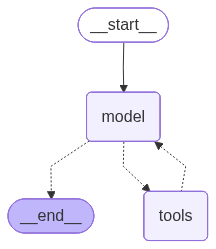

In [31]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq

@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves a specific company,
    year, or document type. Skip for purely semantic queries.
    """
    return rag_qdrant.get_filter_context(query)

@tool
def search_documents(query: str, filters=None):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag_qdrant.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results 
    
# model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

agent = create_agent(
    model=ChatGroq(model="llama-3.3-70b-versatile"),
    tools=[get_filter_context, search_documents],
    system_prompt=(
        "You are a helpful financial document assistant. "
        "For complex questions, break them down into simple sub-questions. "
        "Always use search_documents to retrieve information — never answer from general knowledge. "
        "Use get_filter_context before search_documents when the query involves specific metadata. "
        "Always cite the source document in your answer."
    ),
    checkpointer=InMemorySaver(),
)

agent



In [33]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].text}\n")


RAG Agent ready. Type 'quit' to exit.

